In [30]:
import numpy as np
import scipy.io as sio
import pandas as pd
from scipy import signal
from scipy.signal import butter, lfilter, iirnotch
import matplotlib.pyplot as plt
from emg.acquisition.filters import EMGFilter

# Loading Data and Testing it

In [31]:
sampling_rate = 500

In [32]:
# Load EMG CSV file
data = pd.read_csv("recordings/emg_session_20260919_195805.csv")

# Display the first 5 rows
print(data.head())

      timestamp      emg_0      emg_1      emg_2      emg_3      emg_4  \
0  1.789862e+09  18500.985  33453.360  56487.690  40192.065  31521.150   
1  1.789862e+09  18506.655  33454.080  56463.660  40157.640  31534.380   
2  1.789862e+09  18510.480  33461.325  56503.935  40241.385  31496.625   
3  1.789862e+09  18504.855  33464.520  56520.585  40251.555  31497.075   
4  1.789862e+09  18506.295  33467.220  56507.310  40229.100  31502.385   

       emg_5     emg_6    emg_7  marker  
0  21742.245  7172.055 -721.620     0.0  
1  21736.845  7152.120 -722.925     0.0  
2  21718.035  7123.455 -721.755     0.0  
3  21727.395  7133.760 -727.560     0.0  
4  21726.450  7125.120 -729.765     0.0  


## Setting up important variables

In [33]:
time = data["timestamp"].values
emg_channels = data.filter(like="emg_").values
marker_channels = data["marker"].values

time = time - time[0]

In [34]:
emg_channels.shape

(165928, 8)

In [35]:
time.shape

(165928,)

In [36]:
unique = np.unique(marker_channels)
unique

'''
11 - start of action 1 (flexion)
12 - end of action 1 (flexion)
21 - start of action 2 (extension)
22 - end of action 2 (extension)
'''

'\n11 - start of action 1 (flexion)\n12 - end of action 1 (flexion)\n21 - start of action 2 (extension)\n22 - end of action 2 (extension)\n'

In [37]:
filter = EMGFilter(8, 500, bandpass=(20, 200), notch_freq=60)
filtered_emg_channels = []

chunk_size = 64
i = 0

while i < emg_channels.shape[0]:
    chunk = emg_channels[i:i+chunk_size, :]
    filtered_chunk = filter.apply(np.transpose(chunk))
    filtered_emg_channels.append(np.transpose(filtered_chunk))
    i = i+chunk_size

filtered_emg_channels = np.concatenate(filtered_emg_channels, axis=0)
filtered_emg_channels.shape

(165928, 8)

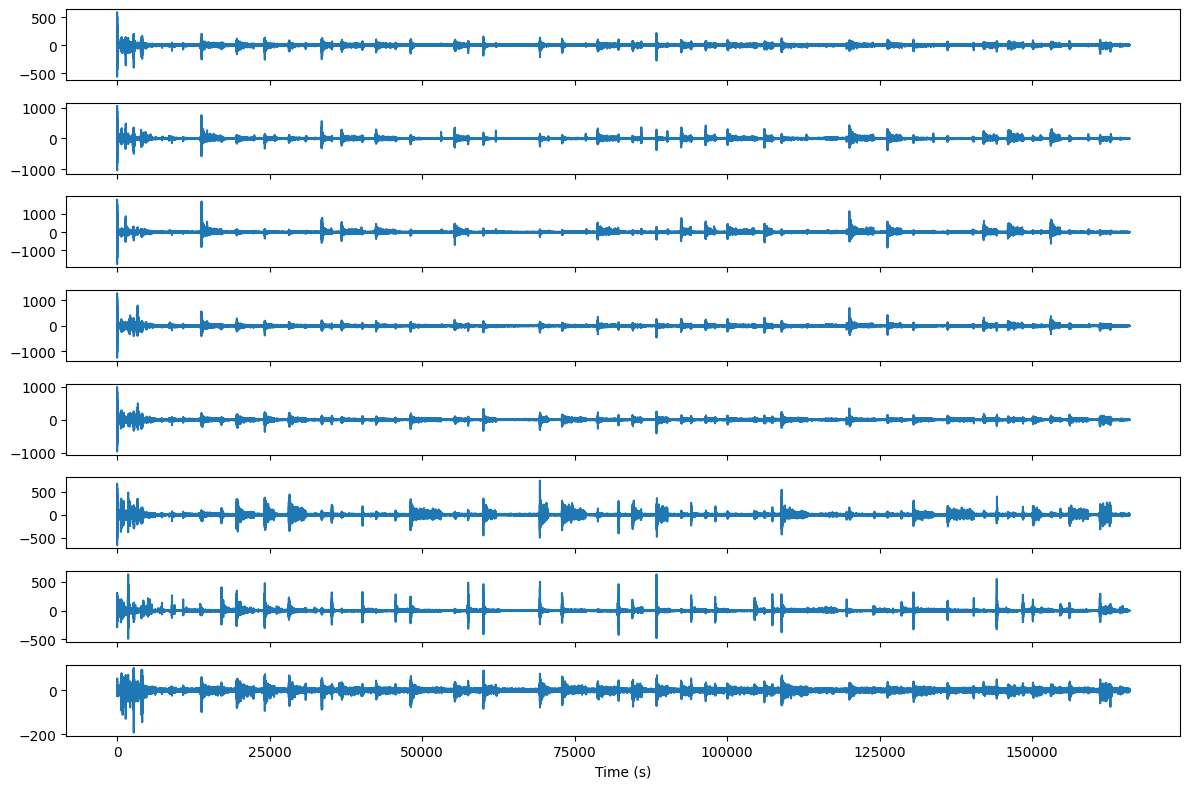

In [38]:
# Create one plot per EMG channel
fig, axes = plt.subplots(
    filtered_emg_channels.shape[1],
    1,
    figsize=(12, 8),
    sharex=True
)
    
for i in range(8):
    axes[i].plot(filtered_emg_channels[:, i])

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

# Setting up Labels

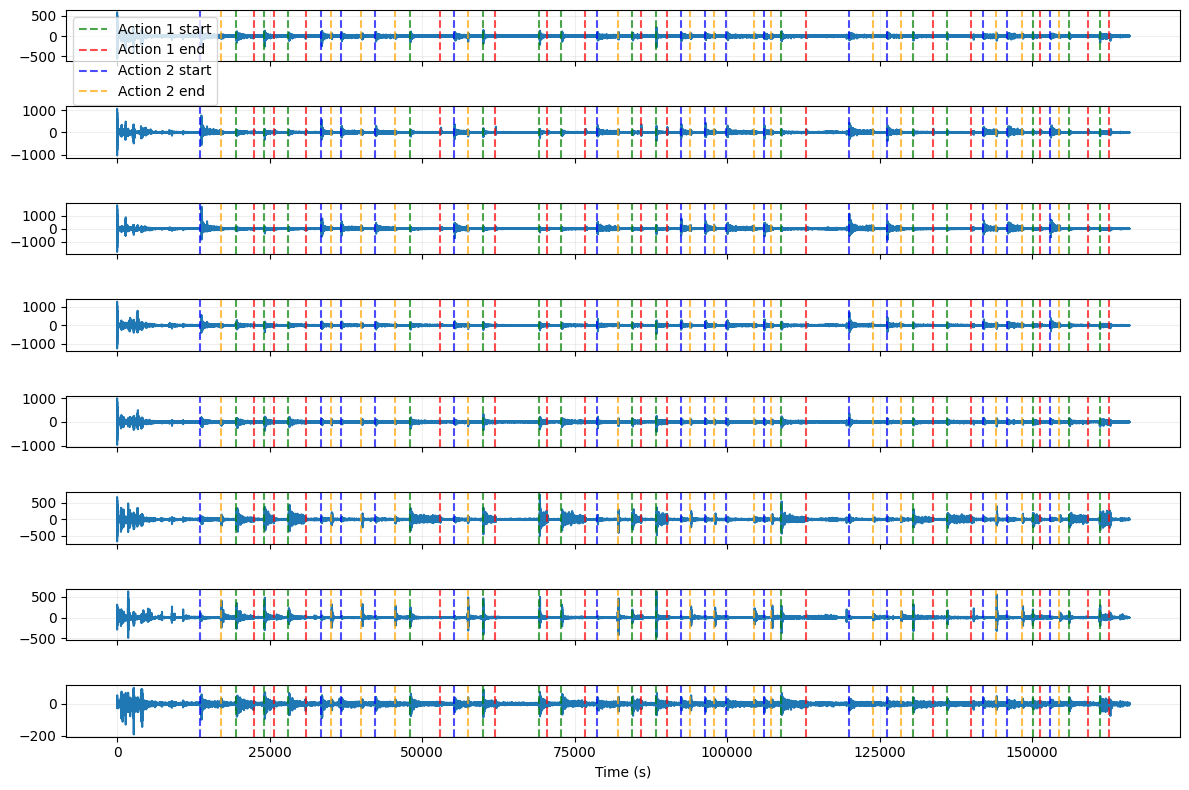

In [39]:
# Create one plot per EMG channel
fig, axes = plt.subplots(
    filtered_emg_channels.shape[1],
    1,
    figsize=(12, 8),
    sharex=True
)

# Plot EMG channels
for i in range(filtered_emg_channels.shape[1]):
    axes[i].plot(filtered_emg_channels[:, i])
    axes[i].grid(alpha=0.2)

# Find marker locations
marker_codes = {
    11: ("Action 1 start", "green"),
    12: ("Action 1 end", "red"),
    21: ("Action 2 start", "blue"),
    22: ("Action 2 end", "orange"),
}

for code, (label, color) in marker_codes.items():
    indices = np.where(marker_channels == code)[0]

    for j, idx in enumerate(indices):
        # Only add the legend label to the first occurrence
        event_label = label if j == 0 else None

        for ax in axes:
            ax.axvline(
                idx,
                color=color,
                linestyle="--",
                alpha=0.7,
                label=event_label
            )

axes[-1].set_xlabel("Time (s)")
axes[0].legend()

plt.tight_layout()
plt.show()

In [40]:
# Getting markers
idx_markers = np.arange(0, len(marker_channels))
idx_markers = idx_markers[marker_channels != 0]
print(idx_markers)

idx_start = idx_markers[::2]
idx_end = idx_markers[1::2]
print(marker_channels[idx_start])
print(marker_channels[idx_end])

for i in range(len(idx_start)):
    print(f"{marker_channels[idx_start[i]]}-{marker_channels[idx_end[i]]}: {idx_start[i]} - {idx_end[i]}")


raw_label = np.zeros_like(marker_channels)

# Set label outputs to constant
for i in range(len(idx_start)):

    marker = marker_channels[idx_start[i]] // 10

    raw_label[idx_start[i]:idx_end[i]] = marker

[ 13510  17014  19426  22388  24076  25740  28070  30908  33386  35072
  36720  40060  42336  45508  48006  52984  55228  57476  59938  61996
  69174  70506  72816  76660  78628  82102  84352  85824  88288  90168
  92380  93976  96374  97910  99886 104368 105996 107162 108780 112896
 119914 123856 126200 128476 130428 133690 136036 139968 142000 144090
 145940 148370 150050 151298 152904 154460 155990 159076 161076 162548]
[21. 11. 11. 11. 21. 21. 21. 11. 21. 11. 11. 11. 21. 11. 11. 21. 21. 21.
 21. 11. 21. 21. 11. 11. 21. 21. 11. 21. 11. 11.]
[22. 12. 12. 12. 22. 22. 22. 12. 22. 12. 12. 12. 22. 12. 12. 22. 22. 22.
 22. 12. 22. 22. 12. 12. 22. 22. 12. 22. 12. 12.]
21.0-22.0: 13510 - 17014
11.0-12.0: 19426 - 22388
11.0-12.0: 24076 - 25740
11.0-12.0: 28070 - 30908
21.0-22.0: 33386 - 35072
21.0-22.0: 36720 - 40060
21.0-22.0: 42336 - 45508
11.0-12.0: 48006 - 52984
21.0-22.0: 55228 - 57476
11.0-12.0: 59938 - 61996
11.0-12.0: 69174 - 70506
11.0-12.0: 72816 - 76660
21.0-22.0: 78628 - 82102
11

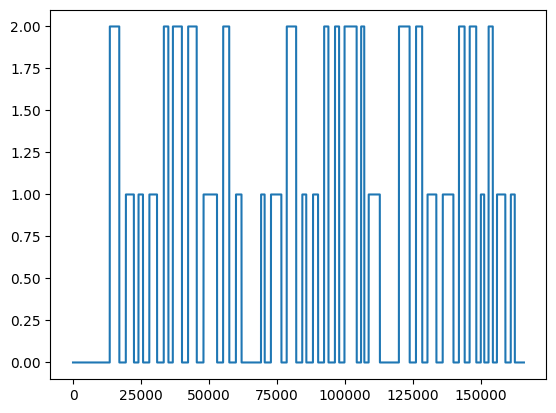

In [41]:
plt.plot(raw_label)

In [42]:
# Truncate
X_emg = filtered_emg_channels[10000:, :]
Y_label = raw_label[10000:]
plot_markers = marker_channels[10000:]


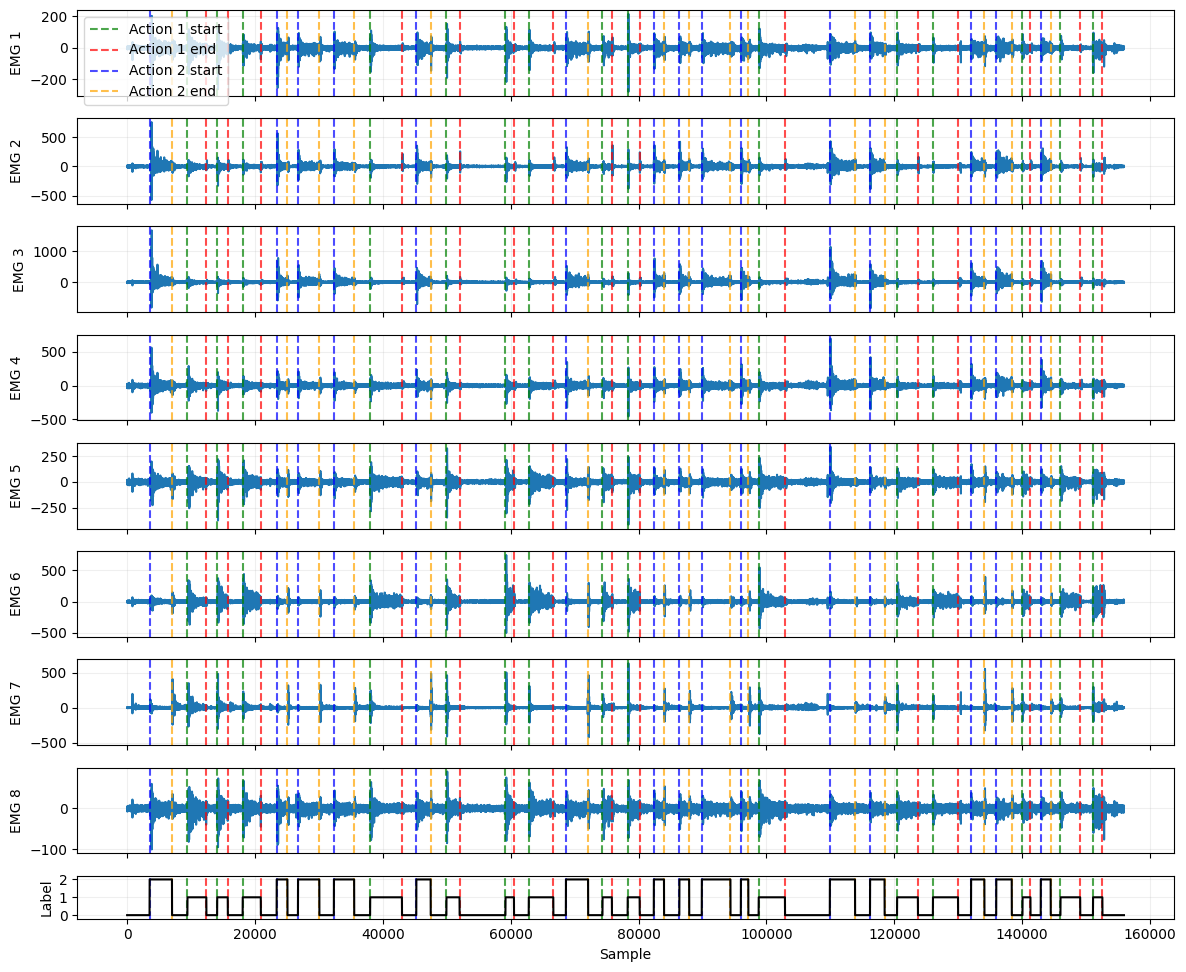

In [43]:
# Number of EMG channels
n_channels = X_emg.shape[1]

# Create EMG plots + 1 plot for raw_label
fig, axes = plt.subplots(
    n_channels + 1,
    1,
    figsize=(12, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [1] * n_channels + [0.5]}
)

# -------------------------
# Plot EMG channels
# -------------------------
for i in range(n_channels):
    axes[i].plot(X_emg[:, i])
    axes[i].set_ylabel(f"EMG {i + 1}")
    axes[i].grid(alpha=0.2)

# -------------------------
# Find marker locations
# -------------------------
marker_codes = {
    11: ("Action 1 start", "green"),
    12: ("Action 1 end", "red"),
    21: ("Action 2 start", "blue"),
    22: ("Action 2 end", "orange"),
}

for code, (label, color) in marker_codes.items():
    indices = np.where(plot_markers == code)[0]

    for j, idx in enumerate(indices):
        event_label = label if j == 0 else None

        for ax in axes:
            ax.axvline(
                idx,
                color=color,
                linestyle="--",
                alpha=0.7,
                label=event_label
            )

# -------------------------
# Plot raw_label at bottom
# -------------------------
axes[-1].plot(
    Y_label,
    color="black",
    linewidth=1.5
)

axes[-1].set_ylabel("Label")
axes[-1].set_xlabel("Sample")
axes[-1].set_yticks([0, 1, 2])
axes[-1].set_ylim(-0.2, 2.2)
axes[-1].grid(alpha=0.2)

# Legend for marker lines
axes[0].legend()

plt.tight_layout()
plt.show()

# Training the Model

In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import copy

In [45]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [46]:
num_classes = 3

val_idx = int(0.8*len(Y_label))
test_idx = int(0.9*len(Y_label))

X = {}
y = {}

X["Train"] = X_emg[:val_idx , :]
y["Train"] = Y_label[:val_idx]

X["Val"] = X_emg[val_idx:test_idx, :]
y["Val"] = Y_label[val_idx:test_idx]

X["Test"] = X_emg[test_idx:, :]
y["Test"] = Y_label[test_idx:]

In [47]:
classes, counts = np.unique(y["Train"], return_counts=True)
weights = 1.0 / counts   # inverse frequency
weights = weights / weights.sum()  # normalize (optional)

class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print(class_weights)  # e.g., tensor([0.25, 0.1667, 0.5])

tensor([0.2022, 0.4117, 0.3861])


In [48]:
step = 20
window_size = int(4*sampling_rate)

class EEGDataset(Dataset):
    def __init__(self, data_type):
        self.data_type = data_type
    
    def __len__(self):
        return ( len(y[self.data_type]) - window_size ) // step
    
    def __getitem__(self, idx):
        i = int(idx*step)

        temp_emg = X[self.data_type][ i:i+window_size, : ]

        # temp_emg -= np.mean(temp_emg, axis=1, keepdims=True)

        # temp_mean = np.mean(temp_emg, axis=0, keepdims=True)
        # temp_std = np.std(temp_emg, axis=0, keepdims=True)

        # temp_emg = (temp_emg - temp_mean) / temp_std

        # Preprocess
        temp_label = y[self.data_type][i+window_size-100]

        # Get the EEG data and corresponding label
        eeg = torch.tensor(temp_emg, dtype=torch.float32)
        label = torch.tensor(temp_label, dtype=torch.long)

        return eeg, label
    
train_dataset = EEGDataset("Train")
val_dataset = EEGDataset("Val")
test_dataset = EEGDataset("Test")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [49]:
from collections import Counter

labels = [train_dataset[i][1].item() for i in range(len(train_dataset))]
counts = Counter(labels)

print(counts)

Counter({0: 2994, 2: 1622, 1: 1521})


In [50]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.hidden_size = hidden_size
        self.attn = nn.Linear(self.hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, encoder_outputs, hidden):

        seq_len = encoder_outputs.size(1)
        h_tiled = hidden.unsqueeze(1).repeat(1, seq_len, 1)
        energy = torch.tanh(self.attn(torch.cat((encoder_outputs, h_tiled), dim=2)))
        attn_weights = torch.softmax(self.v(energy), dim=1)
        context_vector = torch.sum(attn_weights * encoder_outputs, dim=1)

        return context_vector

class DPARSEncoder(nn.Module):
    def __init__(self, input_size, encode_size, num_classes):
        super(DPARSEncoder, self).__init__()
        second_size = input_size*2
        
        self.bn1 = nn.BatchNorm1d(second_size)
        self.bn2 = nn.BatchNorm1d(encode_size)
        self.dropout = nn.Dropout(p=0.3)
        self.attention = Attention(2*encode_size)

        self.depthwise1 = nn.Conv1d(
            input_size, input_size, kernel_size=64, stride = 16, groups=input_size, bias=False)
        self.pointwise1 = nn.Conv1d(input_size, second_size, kernel_size=1)


        self.depthwise2 = nn.Conv1d(
            second_size, second_size, kernel_size=16, stride = 4, groups=second_size, bias=False)
        self.pointwise2 = nn.Conv1d(second_size, encode_size, kernel_size=1)

        self.fc1 = nn.Linear(encode_size, num_classes)
        self.relu = nn.ReLU()


    def forward(self, x):

        # Input -> (batch_size, 2000, 8)
        x = x.permute(0, 2, 1)
        x = self.depthwise1(x)  # output: (batch, 64, 48)
        x = self.pointwise1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        # print(x.shape)


        x = self.depthwise2(x)  # output: (batch, 64, 48)
        x = self.pointwise2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = x.permute(0, 2, 1)
        x = self.attention(x, x[:, -1, :])
        # print(x.shape)

        return self.fc1(x)

In [51]:
model = DPARSEncoder(8, 16, 3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)   # optimize all parameters
criterion = nn.CrossEntropyLoss(weight=class_weights)

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
counter = 0

for epoch in range(75):
    
    # Train the data
    model.train()
    running_loss = 0.0
    for inputs, label in train_loader:
        # Inputs are in shape (batch_size, channels, timepoints)
        # Need to transform to (batch_size, 1, channels, timepoints)
        inputs = inputs.to(device)
        label = label.to(device)
        
        model_output = model(inputs)
        loss = criterion(model_output, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # Validate Data
    model.eval()
    val_acc = 0
    with torch.no_grad():
        for inputs, label in val_loader:
            # Inputs are in shape (batch_size, channels, timepoints)
            # Need to transform to (batch_size, 1, channels, timepoints)
            inputs = inputs.to(device)
            label = label.to(device)
            
            model_output = model(inputs)
            pred = model_output.argmax(dim=1, keepdim=True)
            val_acc += pred.eq(label.view_as(pred)).sum().item()

    # Print to see status
    print(f'Epoch {epoch+1}, Training Loss: {running_loss/len(train_loader):.3f}, Validation Acc: {val_acc/len(val_loader.dataset):.3f}%')

    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter = counter + 1

    if counter > 10:
        break

Epoch 1, Training Loss: 0.910, Validation Acc: 0.641%
Epoch 2, Training Loss: 0.542, Validation Acc: 0.801%
Epoch 3, Training Loss: 0.418, Validation Acc: 0.859%
Epoch 4, Training Loss: 0.338, Validation Acc: 0.892%
Epoch 5, Training Loss: 0.292, Validation Acc: 0.904%
Epoch 6, Training Loss: 0.238, Validation Acc: 0.931%
Epoch 7, Training Loss: 0.206, Validation Acc: 0.935%
Epoch 8, Training Loss: 0.188, Validation Acc: 0.941%
Epoch 9, Training Loss: 0.175, Validation Acc: 0.940%
Epoch 10, Training Loss: 0.166, Validation Acc: 0.946%
Epoch 11, Training Loss: 0.155, Validation Acc: 0.956%
Epoch 12, Training Loss: 0.157, Validation Acc: 0.950%
Epoch 13, Training Loss: 0.146, Validation Acc: 0.950%
Epoch 14, Training Loss: 0.135, Validation Acc: 0.957%
Epoch 15, Training Loss: 0.132, Validation Acc: 0.960%
Epoch 16, Training Loss: 0.129, Validation Acc: 0.962%
Epoch 17, Training Loss: 0.126, Validation Acc: 0.965%
Epoch 18, Training Loss: 0.127, Validation Acc: 0.960%
Epoch 19, Training 

In [52]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

# Example usage:
# model = SomeModel()  # Replace with your actual model
encoder_count = count_parameters(model)
# rnn = count_parameters(rnn_DPARS)
print(f'The model has {encoder_count} parameters.')

The model has 2387 parameters.


(64,)
(128,)
(192,)
(256,)
(320,)
(384,)
(448,)
(512,)
(576,)
(640,)
accuracy = 93.37260677466863
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


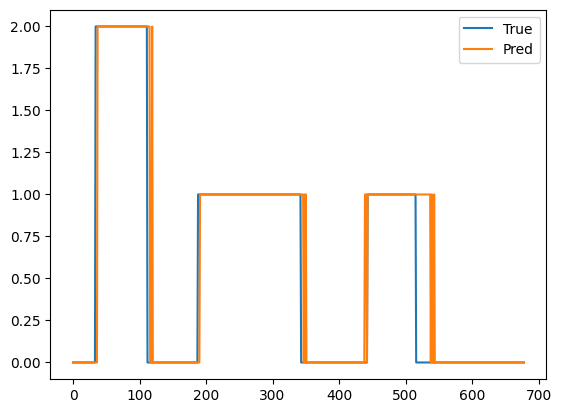

In [53]:
model.load_state_dict(best_model_wts)
# test
pred_list = []
true_list = []
flag = 0

with torch.no_grad():
    n_correct = 0
    n_samples = 0
    for eeg, labels in test_loader:
        eeg = eeg.to(device)
        labels = labels.to(device)
        outputs = model(eeg)
        
        _, predictions = torch.max(outputs, 1)
        n_samples += labels.shape[0]
        n_correct += (predictions==labels).sum().item()

        if flag == 0:
            pred_list = predictions.cpu().detach().numpy()
            true_list = labels.cpu().detach().numpy()
            flag = 1
        else:
            pred = predictions.cpu().detach().numpy()
            true = labels.cpu().detach().numpy()

            print(pred_list.shape)
            pred_list = np.concatenate((pred_list, pred))
            true_list = np.concatenate((true_list, true))
        
    acc = 100 * (n_correct/n_samples)
    print(f'accuracy = {acc}')

    print(predictions)
    print(labels)


plt.plot(true_list, label="True")
plt.plot(pred_list, label="Pred")
plt.legend()

Probability shape: (679, 3)
True shape: (679,)
Raw accuracy:    93.37%
Smoothed accuracy: 91.16%


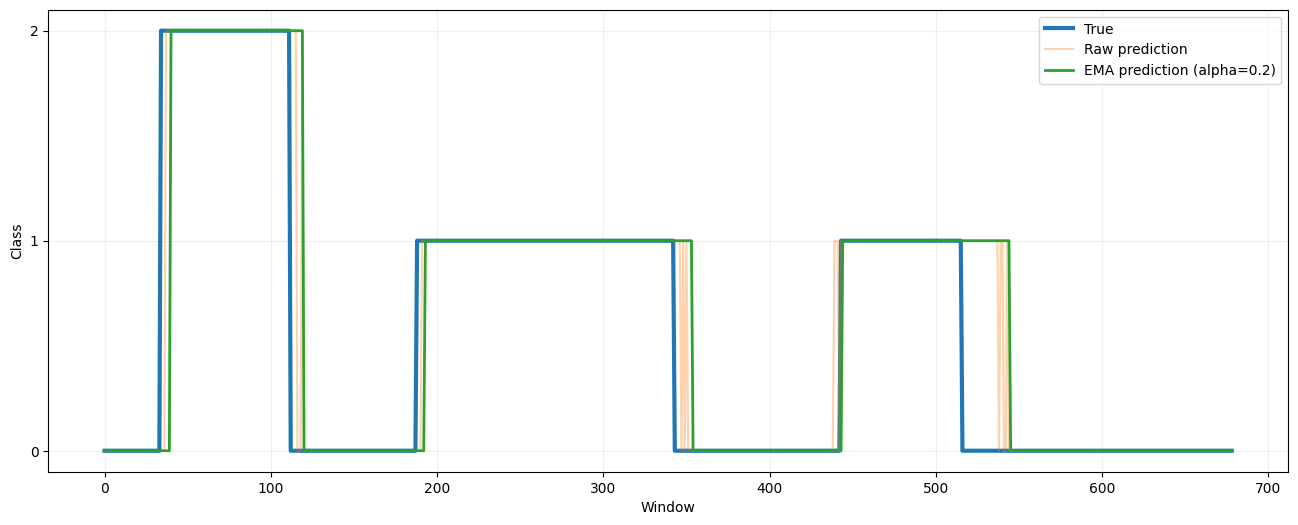

In [54]:
import numpy as np
import torch
import matplotlib.pyplot as plt


def causal_ema(probs, alpha=0.2):
    """
    Causal exponential moving average.

    Parameters
    ----------
    probs : np.ndarray
        Shape: (T, num_classes)
        Class probabilities at each timestep.

    alpha : float
        Smoothing factor.
        1.0 = no smoothing
        smaller = more smoothing

    Returns
    -------
    smoothed : np.ndarray
        Shape: (T, num_classes)
    """

    probs = np.asarray(probs)

    smoothed = np.zeros_like(probs)

    # Initialize with the first prediction
    smoothed[0] = probs[0]

    # Causal EMA:
    # smoothed[t] only depends on current and previous values
    for t in range(1, len(probs)):
        smoothed[t] = (
            alpha * probs[t]
            + (1.0 - alpha) * smoothed[t - 1]
        )

    return smoothed


# ---------------------------------------------------------
# TEST / REAL-TIME INFERENCE
# ---------------------------------------------------------

model.load_state_dict(best_model_wts)
model.eval()

prob_list = []
true_list = []

with torch.no_grad():

    for eeg, labels in test_loader:

        eeg = eeg.to(device)
        labels = labels.to(device)

        # Model output
        outputs = model(eeg)

        # Convert logits -> probabilities
        probs = torch.softmax(outputs, dim=1)

        # Save probabilities
        prob_list.append(probs.cpu().numpy())

        # Save ground truth
        true_list.append(labels.cpu().numpy())


# ---------------------------------------------------------
# Combine batches
# ---------------------------------------------------------

prob_list = np.concatenate(prob_list, axis=0)
true_list = np.concatenate(true_list, axis=0)

print("Probability shape:", prob_list.shape)
print("True shape:", true_list.shape)


# ---------------------------------------------------------
# RAW PREDICTIONS
# ---------------------------------------------------------

raw_pred = np.argmax(prob_list, axis=1)


# ---------------------------------------------------------
# CAUSAL EMA
# ---------------------------------------------------------

alpha = 0.2

smooth_prob = causal_ema(
    prob_list,
    alpha=alpha
)

# Convert smoothed probabilities to classes
smooth_pred = np.argmax(smooth_prob, axis=1)


# ---------------------------------------------------------
# ACCURACY
# ---------------------------------------------------------

raw_acc = np.mean(raw_pred == true_list) * 100
smooth_acc = np.mean(smooth_pred == true_list) * 100

print(f"Raw accuracy:    {raw_acc:.2f}%")
print(f"Smoothed accuracy: {smooth_acc:.2f}%")


# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------

start = 0
end = min(2000, len(true_list))

plt.figure(figsize=(16, 6))

plt.plot(
    true_list[start:end],
    label="True",
    linewidth=3
)

plt.plot(
    raw_pred[start:end],
    label="Raw prediction",
    alpha=0.35
)

plt.plot(
    smooth_pred[start:end],
    label=f"EMA prediction (alpha={alpha})",
    linewidth=2
)

plt.yticks([0, 1, 2])

plt.xlabel("Window")
plt.ylabel("Class")

plt.legend()
plt.grid(alpha=0.2)

plt.show()


In [57]:
step = 20
window_size = int(4*sampling_rate)

pred_label = []
true_label = []


model.eval()
with torch.no_grad():
    i=0
    while i <  len(X_emg) - window_size:
        temp_eeg = X_emg[ i:i+window_size, : ]

        # Preprocess EMG
        # temp_eeg -= np.mean(temp_eeg, axis=1, keepdims=True)
        # temp_mean = np.mean(temp_eeg, axis=0, keepdims=True)
        # temp_std = np.std(temp_eeg, axis=0, keepdims=True)
        # temp_eeg = (temp_eeg - temp_mean) / temp_std

        # Preprocess
        temp_label = Y_label[i+window_size-125]
        true_label.append(temp_label)

        temp_eeg = torch.tensor(temp_eeg, dtype=torch.float32).unsqueeze(0).to(device)
        outputs = model(temp_eeg)
        
        predictions = outputs.argmax(dim=1, keepdim=True)
        pred = predictions.cpu().detach().numpy()[0][0]

        pred_label.append(pred)
        i += step


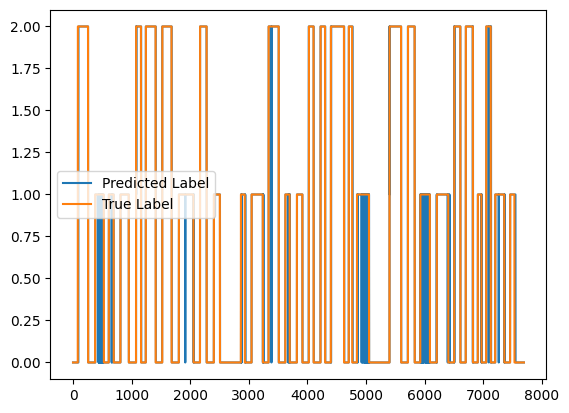

In [58]:
pred_label = np.array(pred_label)
true_label = np.array(true_label)
plt.plot(pred_label, label='Predicted Label')
plt.plot(true_label, label='True Label')
plt.legend()
plt.show()

Raw accuracy:      0.9621
Smoothed accuracy: 0.9541


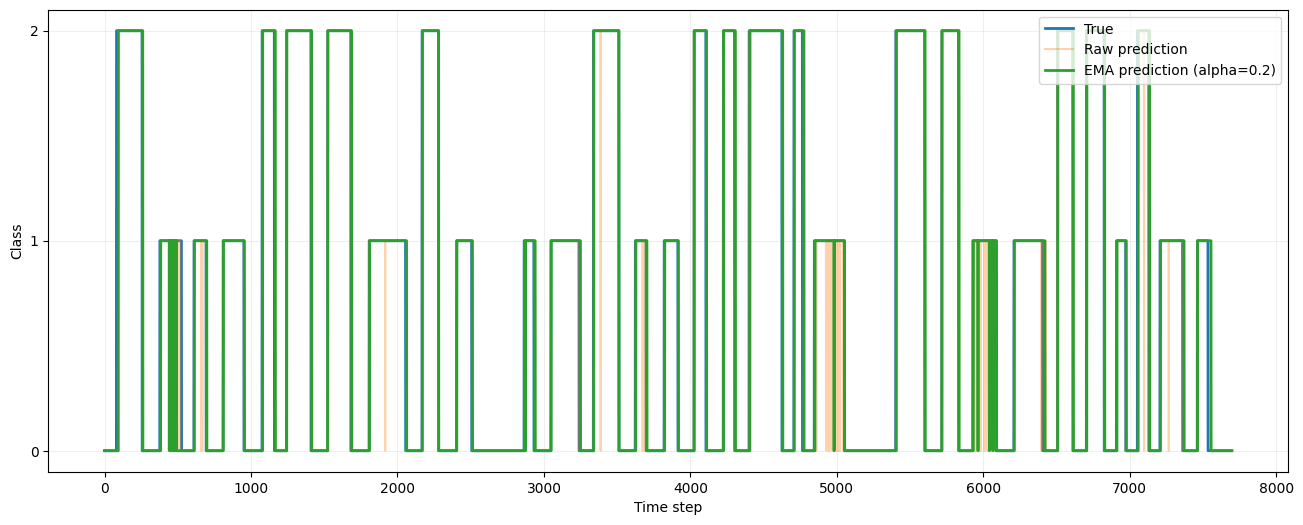

In [59]:
step = 20
window_size = int(4 * sampling_rate)

# EMA smoothing factor
alpha = 0.2

pred_label = []
pred_label_raw = []
true_label = []

# Previous EMA probabilities
ema_probs = None

model.eval()

with torch.no_grad():

    i = 0

    while i < len(X_emg) - window_size:

        # --------------------------------------------------
        # Get window
        # --------------------------------------------------

        temp_eeg = X_emg[i:i + window_size, :].copy()

        # --------------------------------------------------
        # Preprocess EMG
        # --------------------------------------------------

        # temp_eeg -= np.mean(
        #     temp_eeg,
        #     axis=1,
        #     keepdims=True
        # )

        # temp_mean = np.mean(
        #     temp_eeg,
        #     axis=0,
        #     keepdims=True
        # )

        # temp_std = np.std(
        #     temp_eeg,
        #     axis=0,
        #     keepdims=True
        # )

        # temp_eeg = (
        #     temp_eeg - temp_mean
        # ) / (temp_std + 1e-8)

        # --------------------------------------------------
        # True label
        # --------------------------------------------------

        temp_label = Y_label[i + window_size - 125]
        true_label.append(temp_label)

        # --------------------------------------------------
        # Model inference
        # --------------------------------------------------

        temp_eeg = torch.tensor(
            temp_eeg,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        outputs = model(temp_eeg)

        # --------------------------------------------------
        # Raw prediction
        # --------------------------------------------------

        raw_pred = outputs.argmax(dim=1).item()
        pred_label_raw.append(raw_pred)

        # --------------------------------------------------
        # Convert logits -> probabilities
        # --------------------------------------------------

        probs = torch.softmax(outputs, dim=1)

        # Shape: (3,)
        probs = probs.cpu().numpy()[0]

        # --------------------------------------------------
        # Causal EMA
        # --------------------------------------------------

        if ema_probs is None:

            # First prediction initializes EMA
            ema_probs = probs.copy()

        else:

            ema_probs = (
                alpha * probs
                + (1.0 - alpha) * ema_probs
            )

        # --------------------------------------------------
        # Smoothed prediction
        # --------------------------------------------------

        pred = np.argmax(ema_probs)
        pred_label.append(pred)

        # --------------------------------------------------
        # Next window
        # --------------------------------------------------

        i += step


# ----------------------------------------------------------
# Convert to numpy
# ----------------------------------------------------------

pred_label = np.array(pred_label)
pred_label_raw = np.array(pred_label_raw)
true_label = np.array(true_label)


# ----------------------------------------------------------
# Accuracy
# ----------------------------------------------------------

raw_accuracy = np.mean(
    pred_label_raw == true_label
)

smooth_accuracy = np.mean(
    pred_label == true_label
)

print(f"Raw accuracy:      {raw_accuracy:.4f}")
print(f"Smoothed accuracy: {smooth_accuracy:.4f}")


# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(16, 6))

plt.plot(
    true_label,
    label="True",
    linewidth=2
)

plt.plot(
    pred_label_raw,
    label="Raw prediction",
    alpha=0.35
)

plt.plot(
    pred_label,
    label=f"EMA prediction (alpha={alpha})",
    linewidth=2
)

plt.yticks([0, 1, 2])
plt.xlabel("Time step")
plt.ylabel("Class")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [60]:
torch.save(model.state_dict(), f"model.pth")